In [5]:
import pandas as pd
import numpy as np

In [6]:
file_path = r"C:\Users\Max\Desktop\Dataset for Data Analytics.xlsx"
df = pd.read_excel(file_path)

df = pd.read_excel(file_path)
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [9]:
print("--- Initial Inspection ---")
print(f"Total Rows before cleaning: {len(df)}")
print(f"Missing values per column:\n{df.isnull().sum()}\n")

--- Initial Inspection ---
Total Rows before cleaning: 1200
Missing values per column:
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64



In [11]:
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')
df = df.dropna(subset=['OrderID', 'CustomerID'])

In [12]:
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df = df.drop_duplicates(keep='first')
    print(f"-> Removed {duplicate_count} duplicate row(s).")
else:
    print("-> No duplicate rows detected.")

-> No duplicate rows detected.


In [17]:
string_columns = df.select_dtypes(include=['object']).columns
for col in string_columns:
    df[col] = df[col].astype(str).str.strip()
    
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    
    df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce').astype(int)
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce').round(2)

df['TotalPrice'] = (df['Quantity'] * df['UnitPrice']).round(2)

In [19]:
df.describe(include='all')
print("Mean Quantity:", df['Quantity'].mean())
print("Median Quantity:", df['Quantity'].median())
print("Mode Quantity:", df['Quantity'].mode()[0])


Mean Quantity: 2.9458333333333333
Median Quantity: 3.0
Mode Quantity: 1


C:\Users\Max\AppData\Local\Temp/ipykernel_6816/3691965898.py:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  df.describe(include='all')


<AxesSubplot:xlabel='Date'>

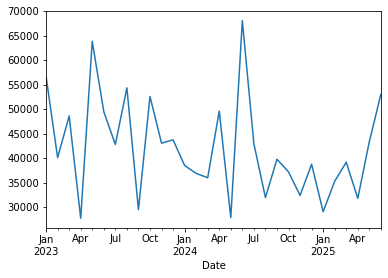

In [20]:
df.groupby(df['Date'].dt.to_period("M"))['TotalPrice'].sum().plot(kind='line')


<AxesSubplot:xlabel='TotalPrice'>

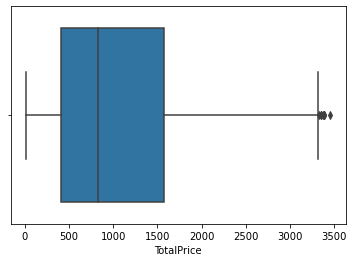

In [21]:
import seaborn as sns
sns.boxplot(x=df['TotalPrice'])


<AxesSubplot:>

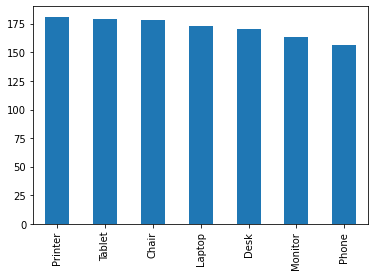

In [22]:
df['Product'].value_counts().plot(kind='bar')


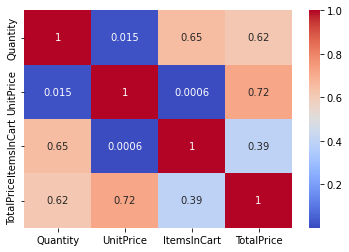

In [23]:
import matplotlib.pyplot as plt
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()
